<a href="https://colab.research.google.com/github/Sisi198/EEG-Study/blob/openNeuro-open-dataset-prac/automatised%20the%20EEG%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne python-picard mne-icalabel -q

import mne
import numpy as np
import pandas as pd
import gc
import os
from mne.preprocessing import ICA
from mne_icalabel import label_components

print("All libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
All libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [ ]:
def preprocess_subject(subject_id):
    print(f"\n{'='*50}")
    print(f"Processing sub-{subject_id}...")
    print(f"{'='*50}")

    # 1. download data

    os.system('pip install awscli -q')
    os.system(f'aws s3 sync --no-sign-request s3://openneuro.org/ds006648/sub-{subject_id} /content/ds006648/sub-{subject_id}')

    # 2. checking the files
    set_file = f'/content/ds006648/sub-{subject_id}/eeg/sub-{subject_id}_task-readpoetry_eeg.set'
    if not os.path.exists(set_file):
        print(f"sub-{subject_id}: .set file not found, skipping!")
        return None

    # 3. load the data
    raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)

    # 4. filter the data
    exg_channels = [ch for ch in ['EXG1','EXG2','EXG3','EXG4','EXG5','EXG6','EXG7','EXG8'] if ch in raw.ch_names]
    raw.drop_channels(exg_channels)
    montage = mne.channels.make_standard_montage('biosemi64')
    raw.set_montage(montage, on_missing='warn', verbose=False)
    raw.load_data(verbose=False)
    raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)

    # 5. ICA
    raw_short = raw.copy().crop(tmax=min(3000, raw.times[-1]))
    ica = ICA(n_components=63, method='picard', random_state=42, verbose=False)
    ica.fit(raw_short, verbose=False)

    # 6. ICLabel
    ic_labels = label_components(raw_short, ica, method='iclabel')
    labels = ic_labels['labels']
    proba = ic_labels['y_pred_proba']
    exclude = [i for i, label in enumerate(labels)
               if label not in ['brain', 'other']
               and proba[i].max() > 0.9]
    print(f"sub-{subject_id}: Excluding {len(exclude)} components")
    ica.exclude = exclude
    ica.apply(raw, verbose=False)

    # 7. Epoching
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, event_id={'stimulus': 2},
                        tmin=-4.0, tmax=11.0, baseline=(-4.0, 0),
                        preload=True, verbose=False)
    print(f"sub-{subject_id}: {len(epochs)} epochs created")

    # 8. save to Google Drive
    save_path = '/content/drive/MyDrive/EEG_Study/'
    os.makedirs(save_path, exist_ok=True)
    epochs.save(save_path + f'sub-{subject_id}-epo.fif', overwrite=True)
    print(f"sub-{subject_id}: Saved!")

    return epochs

print("Function defined!")

Function defined!


In [ ]:
subjects = ['002', '003', '004']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-002...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-002: Excluding 5 components
sub-002: 212 epochs created
sub-002: Saved!
Memory cleared for sub-002

Processing sub-003...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-003: Excluding 4 components
sub-003: 212 epochs created
sub-003: Saved!
Memory cleared for sub-003

Processing sub-004...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-004: Excluding 5 components
sub-004: 212 epochs created
sub-004: Saved!
Memory cleared for sub-004

ALL DONE!


In [ ]:
import os
files = os.listdir('/content/drive/MyDrive/EEG_Study/')
print(files)

['sub-001-ica.fif', 'sub-001-preprocessed-raw.fif', 'sub-001-cleaned-raw.fif', 'ERP_Pz_comparison.png', 'ERP_Pz_zoom.png', 'sub-002-epo.fif', 'sub-003-epo.fif', 'sub-004-epo.fif']


In [ ]:
# Making sub-001 epoch file
epochs = preprocess_subject('001')
del epochs
gc.collect()


Processing sub-001...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-001: Excluding 6 components
sub-001: 212 epochs created
sub-001: Saved!


963

In [ ]:
subjects = ['005', '006', '007']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-005...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-005: Excluding 3 components
sub-005: 212 epochs created
sub-005: Saved!
Memory cleared for sub-005

Processing sub-006...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-006: Excluding 7 components
sub-006: 212 epochs created
sub-006: Saved!
Memory cleared for sub-006

Processing sub-007...


/tmp/ipykernel_996/2039527887.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_996/2039527887.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-007: Excluding 7 components
sub-007: 212 epochs created
sub-007: Saved!
Memory cleared for sub-007

ALL DONE!


In [ ]:
  subjects = ['008', '009', '010']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")

NameError: name 'preprocess_subject' is not defined

In [ ]:
!pip install mne python-picard mne-icalabel -q

import mne
import numpy as np
import pandas as pd
import gc
import os
from mne.preprocessing import ICA
from mne_icalabel import label_components

print("All libraries loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 MB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
All libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [ ]:
def preprocess_subject(subject_id):
    print(f"\n{'='*50}")
    print(f"Processing sub-{subject_id}...")
    print(f"{'='*50}")

    # 1. download data

    os.system('pip install awscli -q')
    os.system(f'aws s3 sync --no-sign-request s3://openneuro.org/ds006648/sub-{subject_id} /content/ds006648/sub-{subject_id}')

    # 2. checking the files
    set_file = f'/content/ds006648/sub-{subject_id}/eeg/sub-{subject_id}_task-readpoetry_eeg.set'
    if not os.path.exists(set_file):
        print(f"sub-{subject_id}: .set file not found, skipping!")
        return None

    # 3. load the data
    raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)

    # 4. filter the data
    exg_channels = [ch for ch in ['EXG1','EXG2','EXG3','EXG4','EXG5','EXG6','EXG7','EXG8'] if ch in raw.ch_names]
    raw.drop_channels(exg_channels)
    montage = mne.channels.make_standard_montage('biosemi64')
    raw.set_montage(montage, on_missing='warn', verbose=False)
    raw.load_data(verbose=False)
    raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)

    # 5. ICA
    raw_short = raw.copy().crop(tmax=min(3000, raw.times[-1]))
    ica = ICA(n_components=63, method='picard', random_state=42, verbose=False)
    ica.fit(raw_short, verbose=False)

    # 6. ICLabel
    ic_labels = label_components(raw_short, ica, method='iclabel')
    labels = ic_labels['labels']
    proba = ic_labels['y_pred_proba']
    exclude = [i for i, label in enumerate(labels)
               if label not in ['brain', 'other']
               and proba[i].max() > 0.9]
    print(f"sub-{subject_id}: Excluding {len(exclude)} components")
    ica.exclude = exclude
    ica.apply(raw, verbose=False)

    # 7. Epoching
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    epochs = mne.Epochs(raw, events, event_id={'stimulus': 2},
                        tmin=-4.0, tmax=11.0, baseline=(-4.0, 0),
                        preload=True, verbose=False)
    print(f"sub-{subject_id}: {len(epochs)} epochs created")

    # 8. save to Google Drive
    save_path = '/content/drive/MyDrive/EEG_Study/'
    os.makedirs(save_path, exist_ok=True)
    epochs.save(save_path + f'sub-{subject_id}-epo.fif', overwrite=True)
    print(f"sub-{subject_id}: Saved!")

    return epochs

print("Function defined!")

Function defined!


In [ ]:
subjects = ['008', '009', '010']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-008...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-008: Excluding 4 components
sub-008: 212 epochs created
sub-008: Saved!
Memory cleared for sub-008

Processing sub-009...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:32: RuntimeWarning: Using n_components=63 (resulting in n_components_=63) may lead to an unstable mixing matrix estimation because the ratio between the largest (63) and smallest (4.8e-07) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 30
  ica.fit(raw_short, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the '

sub-009: Excluding 11 components
sub-009: 212 epochs created
sub-009: Saved!
Memory cleared for sub-009

Processing sub-010...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-010: Excluding 7 components
sub-010: 212 epochs created
sub-010: Saved!
Memory cleared for sub-010

ALL DONE!


In [ ]:
subjects = ['011', '012', '013']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-011...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-011: Excluding 3 components
sub-011: 212 epochs created
sub-011: Saved!
Memory cleared for sub-011

Processing sub-012...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-012: Excluding 8 components
sub-012: 212 epochs created
sub-012: Saved!
Memory cleared for sub-012

Processing sub-013...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:32: RuntimeWarning: Using n_components=63 (resulting in n_components_=63) may lead to an unstable mixing matrix estimation because the ratio between the largest (20) and smallest (1e-07) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 18
  ica.fit(raw_short, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'fi

sub-013: Excluding 3 components
sub-013: 212 epochs created
sub-013: Saved!
Memory cleared for sub-013

ALL DONE!


In [ ]:
subjects = ['014', '015', '016']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-014...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:32: RuntimeWarning: Using n_components=63 (resulting in n_components_=63) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (1.6e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 28
  ica.fit(raw_short, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the '

sub-014: Excluding 4 components
sub-014: 212 epochs created
sub-014: Saved!
Memory cleared for sub-014

Processing sub-015...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:32: RuntimeWarning: Using n_components=63 (resulting in n_components_=63) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (8.6e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 37
  ica.fit(raw_short, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the '

sub-015: Excluding 14 components
sub-015: 212 epochs created
sub-015: Saved!
Memory cleared for sub-015

Processing sub-016...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-016: Excluding 7 components
sub-016: 212 epochs created
sub-016: Saved!
Memory cleared for sub-016

ALL DONE!


In [ ]:
subjects = ['017', '018']

for sub in subjects:
    epochs = preprocess_subject(sub)
    del epochs
    gc.collect()
    print(f"Memory cleared for sub-{sub}")

print("\nALL DONE!")


Processing sub-017...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-017: Excluding 3 components
sub-017: 212 epochs created
sub-017: Saved!
Memory cleared for sub-017

Processing sub-018...


/tmp/ipykernel_648/4082883274.py:18: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG7', 'EXG8']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_short, ica, method='iclabel')
/tmp/ipykernel_648/4082883274.py:35: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.prep

sub-018: Excluding 8 components
sub-018: 212 epochs created
sub-018: Saved!
Memory cleared for sub-018

ALL DONE!


In [ ]:
# Checking the epoch file saved in google drive
files = os.listdir('/content/drive/MyDrive/EEG_Study/')
epo_files = sorted([f for f in files if f.endswith('-epo.fif')])
print(f"totla {len(epo_files)} epoch file:")
print(epo_files)

totla 18 epoch file:
['sub-001-epo.fif', 'sub-002-epo.fif', 'sub-003-epo.fif', 'sub-004-epo.fif', 'sub-005-epo.fif', 'sub-006-epo.fif', 'sub-007-epo.fif', 'sub-008-epo.fif', 'sub-009-epo.fif', 'sub-010-epo.fif', 'sub-011-epo.fif', 'sub-012-epo.fif', 'sub-013-epo.fif', 'sub-014-epo.fif', 'sub-015-epo.fif', 'sub-016-epo.fif', 'sub-017-epo.fif', 'sub-018-epo.fif']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading mapping files
from google.colab import files
uploaded = files.upload()  # EEGLAB_Epoch_to_PoemType.xlsx upload
mapping = pd.read_excel('EEGLAB_Epoch_to_PoemType.xlsx')
mapping = mapping.dropna(subset=['PoemType'])

# conditional index
haiku_idx = mapping[mapping['PoemType'] == 'H']['EEGLAB_Epoch'].values - 1
senryu_idx = mapping[mapping['PoemType'] == 'S']['EEGLAB_Epoch'].values - 1
control_idx = mapping[mapping['PoemType'] == 'C']['EEGLAB_Epoch'].values - 1

save_path = '/content/drive/MyDrive/EEG_Study/'

# calculating average ERP of 18 participants1
haiku_erps = []
senryu_erps = []
control_erps = []

for epo_file in epo_files:
    print(f"Loading {epo_file}...")
    epochs = mne.read_epochs(save_path + epo_file, verbose=False)

    pz_idx = epochs.ch_names.index('Pz')

    haiku_erps.append(epochs[haiku_idx].average().data[pz_idx])
    senryu_erps.append(epochs[senryu_idx].average().data[pz_idx])
    control_erps.append(epochs[control_idx].average().data[pz_idx])

# average of 19 participants
times = epochs.times * 1000
haiku_mean = np.mean(haiku_erps, axis=0) * 1e6
senryu_mean = np.mean(senryu_erps, axis=0) * 1e6
control_mean = np.mean(control_erps, axis=0) * 1e6

print("Done!")

Saving EEGLAB_Epoch_to_PoemType.xlsx to EEGLAB_Epoch_to_PoemType.xlsx
Loading sub-001-epo.fif...
Loading sub-002-epo.fif...
Loading sub-003-epo.fif...
Loading sub-004-epo.fif...
Loading sub-005-epo.fif...
Loading sub-006-epo.fif...
Loading sub-007-epo.fif...
Loading sub-008-epo.fif...
Loading sub-009-epo.fif...
Loading sub-010-epo.fif...
Loading sub-011-epo.fif...
Loading sub-012-epo.fif...
Loading sub-013-epo.fif...
Loading sub-014-epo.fif...
Loading sub-015-epo.fif...
Loading sub-016-epo.fif...
Loading sub-017-epo.fif...
Loading sub-018-epo.fif...
Done!


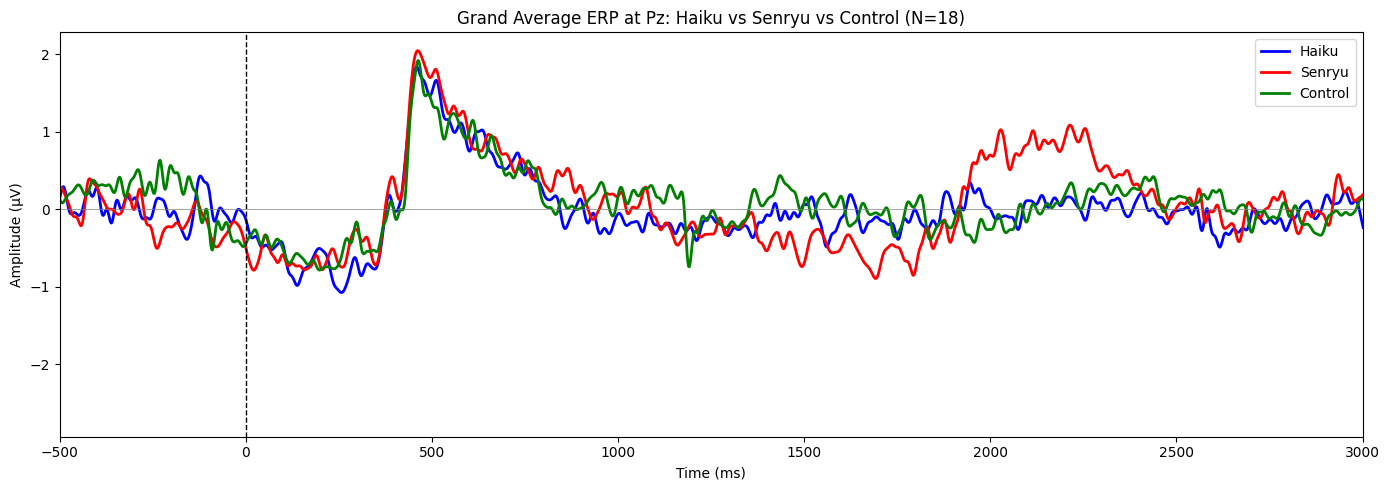

Saved!


In [ ]:
# ERP graph for averaging 18 participants data
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(times, haiku_mean, color='blue', label='Haiku', linewidth=2)
ax.plot(times, senryu_mean, color='red', label='Senryu', linewidth=2)
ax.plot(times, control_mean, color='green', label='Control', linewidth=2)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlim(-500, 3000)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Grand Average ERP at Pz: Haiku vs Senryu vs Control (N=18)')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEG_Study/GrandAverage_ERP_Pz.png', dpi=150)
plt.show()
print("Saved!")